--- Getting Started & Step 1 ---
Missing values before enforcing frequency: 0
Missing values after enforcing frequency and ffill: 0

Inferred Frequency: h
Time span: 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Total observations: 17256

--- Step 2: Quick Exploration ---

Global Descriptive Statistics:


count    17256.000000
mean       151.341910
std        155.813437
min          1.000000
25%         50.000000
50%         93.000000
75%        208.000000
max        977.000000
Name: count, dtype: float64


Daily Resampled Statistics:


count     719.000000
mean     3632.205841
std      2051.337368
min       608.000000
25%      1728.000000
50%      3357.000000
75%      5128.500000
max      8714.000000
Name: count, dtype: float64

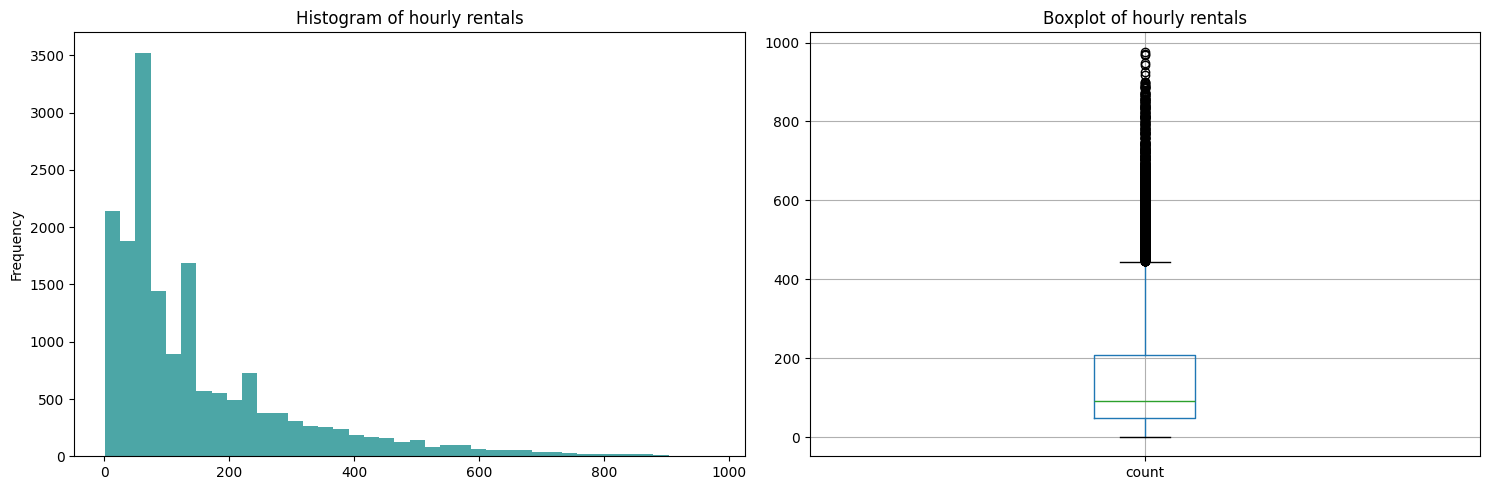


--- Step 3: Essential Visualizations ---


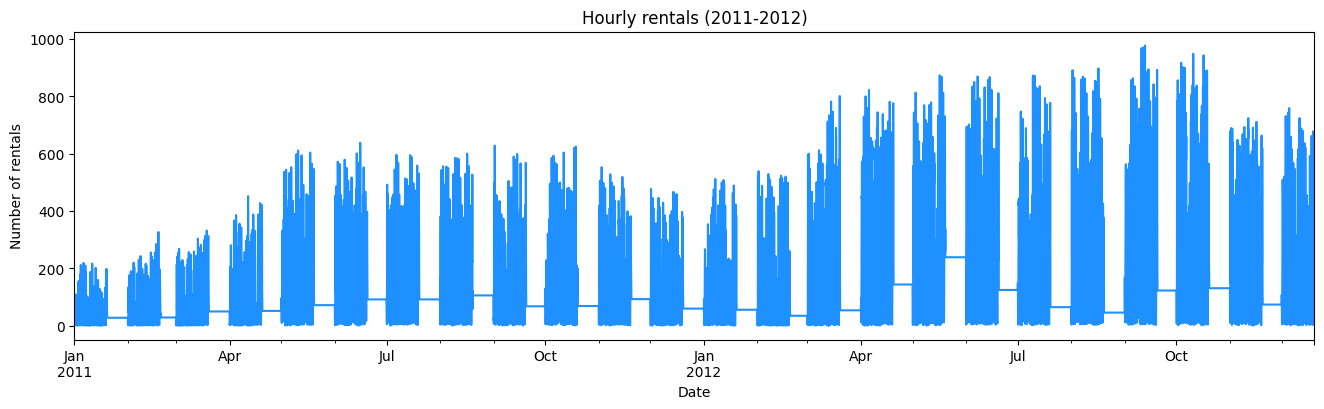

ValueError: Invalid frequency: Y. Failed to parse with error message: ValueError("'Y' is no longer supported for offsets. Please use 'YE' instead.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Getting Started & Step 1: Check the time structure
# ==========================================
print("--- Getting Started & Step 1 ---")
# Load the dataset, ensuring datetime is parsed correctly
try:
    df = pd.read_csv("train.csv", parse_dates=["datetime"])
except FileNotFoundError:
    print("Error: Please ensure 'train.csv' is in the same directory as this notebook.")
    
serie = df.set_index("datetime")["count"].sort_index()

print(f"Missing values before enforcing frequency: {serie.isna().sum()}")

# Enforce hourly frequency and fill missing values using forward fill
serie = serie.asfreq("h")  
serie = serie.ffill()
print(f"Missing values after enforcing frequency and ffill: {serie.isna().sum()}")

print(f"\nInferred Frequency: {serie.index.inferred_freq}")
print(f"Time span: {serie.index.min()} to {serie.index.max()}")
print(f"Total observations: {serie.size}")

# ==========================================
# Step 2: Quick exploration
# ==========================================
print("\n--- Step 2: Quick Exploration ---")
print("\nGlobal Descriptive Statistics:")
display(serie.describe())

print("\nDaily Resampled Statistics:")
display(serie.resample("D").sum().describe())

# Plot Histogram and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

serie.plot(kind="hist", bins=40, alpha=0.7, ax=axes[0], color='teal')
axes[0].set_title("Histogram of hourly rentals")

serie.to_frame("count").boxplot(ax=axes[1])
axes[1].set_title("Boxplot of hourly rentals")

plt.tight_layout()
plt.show()

# ==========================================
# Step 3: Essential visualizations
# ==========================================
print("\n--- Step 3: Essential Visualizations ---")

# 3.1 Global view
plt.figure(figsize=(16, 4))
serie.plot(title="Hourly rentals (2011-2012)", color='dodgerblue')
plt.xlabel("Date")
plt.ylabel("Number of rentals")
plt.show()

# 3.2 Intra-year variations
# Using pd.concat instead of dictionary comprehension to handle leap years (2012 has more days than 2011) safely
years = serie.groupby(pd.Grouper(freq="YE"))
df_years = pd.concat([group.reset_index(drop=True).rename(str(name.year)) for name, group in years], axis=1)

df_years.plot(figsize=(14, 6), subplots=True, sharex=False, sharey=True, legend=True, title="Comparison of 2011 vs 2012")
plt.show()

# 3.3 Weekly and daily cycle
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

serie.resample("D").sum().plot(ax=axes[0], color='coral', title="Daily rentals")

serie.groupby(serie.index.hour).mean().plot(kind="bar", ax=axes[1], color='mediumseagreen')
axes[1].set_title("Average profile by hour")

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
serie.groupby(serie.index.day_name()).mean().reindex(days_order).plot(kind="bar", ax=axes[2], color='orchid')
axes[2].set_title("Average profile by day of week")

plt.tight_layout()
plt.show()

# ==========================================
# Step 4: Autocorrelation and temporal dependencies
# ==========================================
print("\n--- Step 4: Autocorrelation and Lag Plots ---")

# 4.1 Lag plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.plotting.lag_plot(serie, lag=1, s=5, alpha=0.3, ax=axes[0], c='darkorange')
axes[0].set_title("Lag Plot (Lag = 1 Hour)")

pd.plotting.lag_plot(serie, lag=24, s=5, alpha=0.3, ax=axes[1], c='purple')
axes[1].set_title("Lag Plot (Lag = 24 Hours)")
plt.show()

# 4.2 Autocorrelation functions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie, lags=48, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(serie, lags=48, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")
plt.show()